<a href="https://colab.research.google.com/github/jeetb270/Stratify_2026_Dark_Matter/blob/main/stratify_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# READING DATA

cand_sites = pd.read_csv("Data/candidate_sites.csv")
order_log = pd.read_csv("Data/order_log.csv")
pincode_den = pd.read_csv("Data/pincode_density.csv")
store_master = pd.read_csv("Data/store_master.csv")
data_dict = pd.read_csv("Data/data_dictionary.csv")

# Understand data format to clean the data

print("Candidate Sites:\n", cand_sites.head())
print("\nOrder Logs:\n", order_log.head())
print("\nPincode Density:\n", pincode_den.head())
print("\nStore Master:\n", store_master.head())
print("\nData Dictionary:\n", data_dict.head())

Candidate Sites:
   site_id  city  site_lat  site_lon  site_pincode  carpet_area_sqft  \
0   CS-01  Pune   18.5975    73.764        411057              2650   
1   CS-02  Pune   18.5760    73.770        411045              2400   
2   CS-03  Pune   18.4670    73.888        411048              2900   
3   CS-04  Pune   18.5090    73.813        411038              2200   
4   CS-05  Pune   18.5640    73.908        411014              2050   

   monthly_rent_inr  one_time_fitout_cost_inr  
0             82000                   1650000  
1             76000                   1480000  
2             64000                   1520000  
3             88000                   1390000  
4             79000                   1310000  

Order Logs:
      order_id      order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001  2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002  2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003  2026-04-01

In [ ]:
# CLEANING DATA

# Convert date and time columns to datetime objects
order_log['order_timestamp'] = pd.to_datetime(order_log['order_timestamp'])
store_master['go_live_date'] = pd.to_datetime(store_master['go_live_date'])

# Extract the month from the order timestamp for monthly fixed cost calculations later
order_log['order_month'] = order_log['order_timestamp'].dt.to_period('M')

# Create a breach flag: True if actual_delivery_min > promised_delivery_min
order_log['breach'] = order_log['actual_delivery_min'] > order_log['promised_delivery_min']

# Drop any potential duplicates in the order log
order_log = order_log.drop_duplicates(subset=['order_id'])

print("Data cleaning completed.")
print(order_log[['order_id', 'order_timestamp', 'breach']].head())

Data cleaning completed.
     order_id     order_timestamp  breach
0  ORD0000001 2026-04-01 00:14:29   False
1  ORD0000002 2026-04-01 00:15:20   False
2  ORD0000003 2026-04-01 00:27:56   False
3  ORD0000004 2026-04-01 00:28:20   False
4  ORD0000005 2026-04-01 00:28:39   False


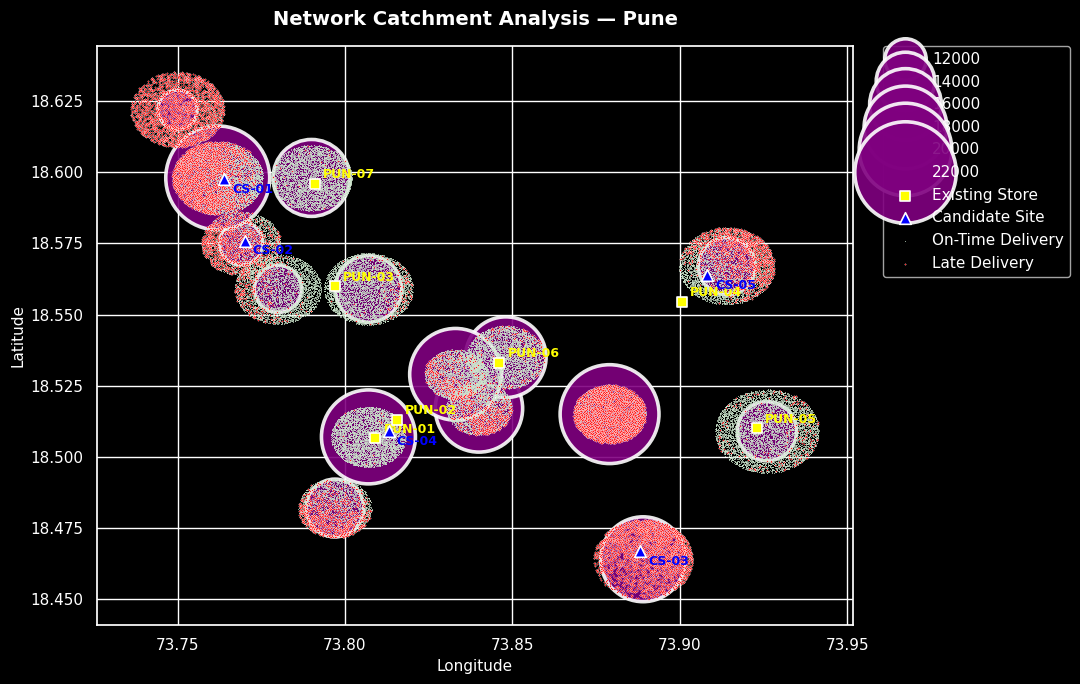

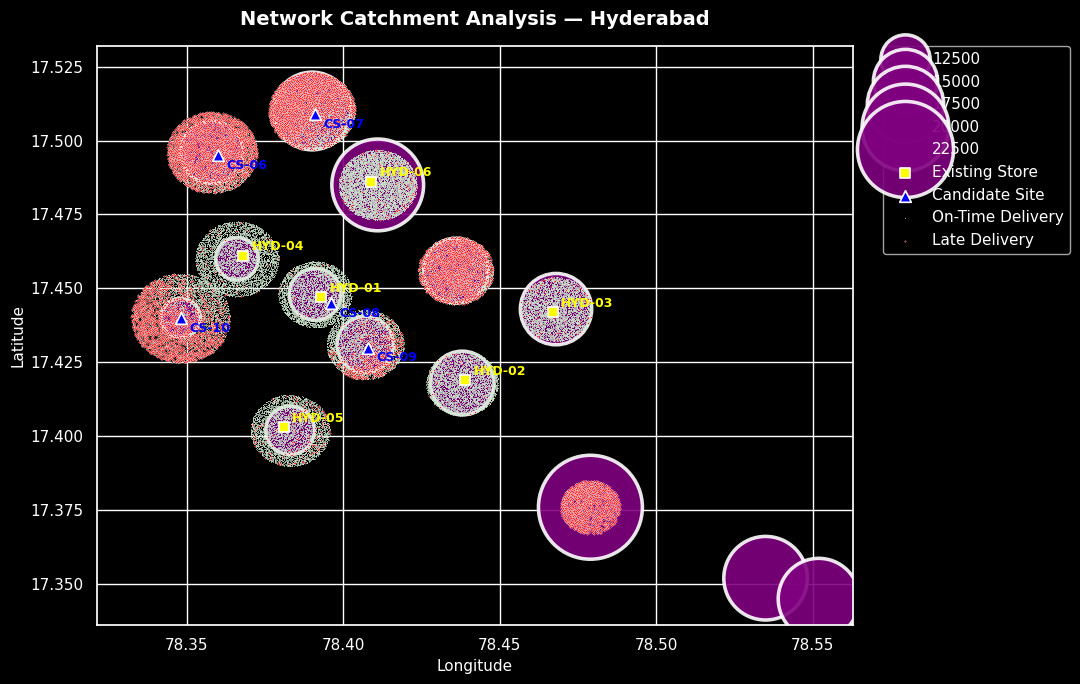

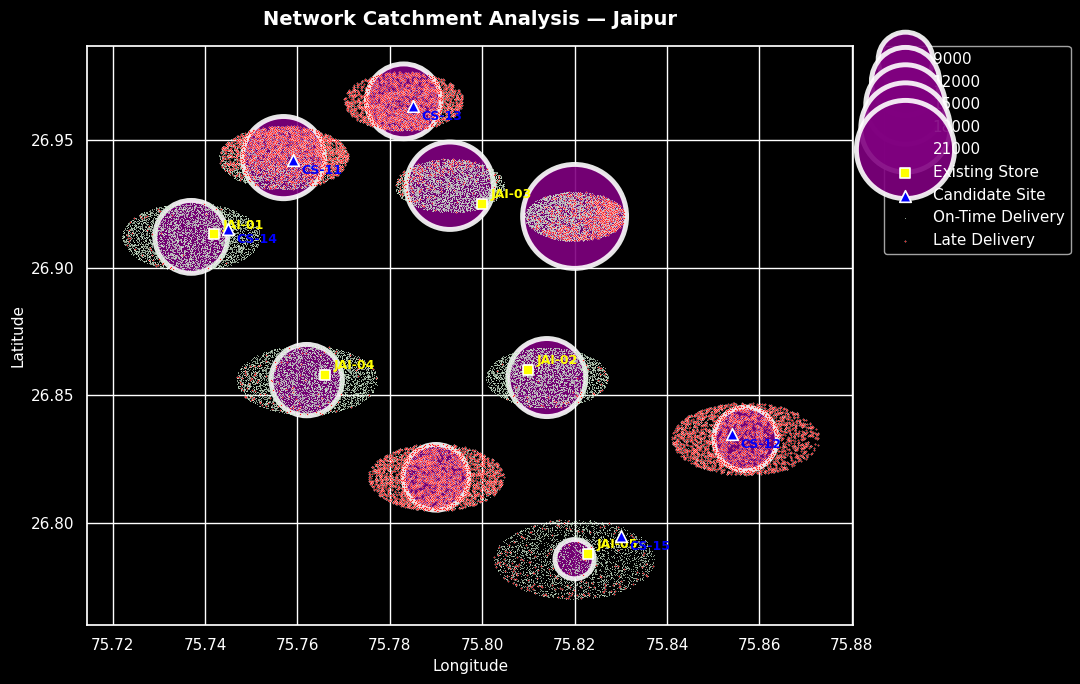

In [14]:
# CREATING A VISUAL

# Set the plot style
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Cities in scope
cities = ['Pune', 'Hyderabad', 'Jaipur']

for city in cities:
    # Filter datasets by city
    city_pincodes = pincode_den[pincode_den['city'] == city]
    city_stores = store_master[store_master['city'] == city]
    city_candidates = cand_sites[cand_sites['city'] == city]
    city_orders = order_log[order_log['city'] == city]

    plt.figure(figsize=(11, 7))

    # 1. Pincode Centroids (Bubble size = Population Density)
    sns.scatterplot(
        data=city_pincodes,
        x='pincode_centroid_lon',
        y='pincode_centroid_lat',
        size='population_density_per_sqkm',
        sizes=(800, 5600),
        alpha=0.90,
        color='purple',
        legend='brief'
    )

    # 2. Existing Active Dark Stores
    plt.scatter(
        city_stores['store_lon'],
        city_stores['store_lat'],
        color='yellow',
        marker='s',        # Square marker
        s=60,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Existing Store'
    )

    # 3. Candidate Dark Store Sites
    plt.scatter(
        city_candidates['site_lon'],
        city_candidates['site_lat'],
        color='blue',
        marker='^',        # Triangle marker
        s=70,
        edgecolor='white',
        linewidth=1.2,
        zorder=5,
        label='Candidate Site'
    )

    on_time = city_orders[city_orders['actual_delivery_min'] <= city_orders['promised_delivery_min']]
    delayed = city_orders[city_orders['actual_delivery_min'] > city_orders['promised_delivery_min']]

    plt.scatter(
        on_time['delivery_lon'],
        on_time['delivery_lat'],
        s=0.2,
        color='green',
        edgecolor='white',
        linewidth=0.2,
        zorder=1,
        label='On-Time Delivery'
    )

    plt.scatter(
        delayed['delivery_lon'],
        delayed['delivery_lat'],
        s=1,
        color='red',
        edgecolor='white',
        linewidth=0.2,
        zorder=1,
        label='Late Delivery'
    )

    # Annotate store IDs
    for _, row in city_stores.iterrows():
        plt.annotate(
            row['store_id'],
            (row['store_lon'], row['store_lat']),
            fontsize=9, fontweight='bold', color='yellow',
            xytext=(6, 4), textcoords='offset points'
        )

    # Annotate candidate site IDs
    for _, row in city_candidates.iterrows():
        plt.annotate(
            row['site_id'],
            (row['site_lon'], row['site_lat']),
            fontsize=9, fontweight='bold', color='blue',
            xytext=(6, -10), textcoords='offset points'
        )

    # Styling and Labels
    plt.title(f'Network Catchment Analysis — {city}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Longitude', fontsize=11)
    plt.ylabel('Latitude', fontsize=11)

    # Place legend outside plot area
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    plt.show()

In [24]:
# KEY TASK 1:

cost_to_serve = pd.merge(order_log, store_master, on = ['store_id', 'city'], how = 'left')

cost_to_serve['no_of_orders'] = cost_to_serve.groupby(['store_id', 'order_month'])['order_id'].transform('count')

# Vectorized Distance Calculation
lat = cost_to_serve['delivery_lat'] - cost_to_serve['store_lat']
lon = cost_to_serve['delivery_lon'] - cost_to_serve['store_lon']
lat_mean = (cost_to_serve['delivery_lat'] + cost_to_serve['store_lat']) / 2.0

distance = np.sqrt(
    (lat * 111.0) ** 2 +
    (lon * 111.0 * np.cos(np.radians(lat_mean))) ** 2
)

# Vectorized Cost Allocation
breach_penalty = np.where(cost_to_serve['breach'] == True, 30.0, 0.0)

# Total monthly store overhead divided by orders fulfilled by that store in that month
fixed_cost_per_order = (
    cost_to_serve['monthly_rent_inr'] + cost_to_serve['monthly_fixed_cost_inr']
) / cost_to_serve['no_of_orders']

# Combine all components into final cost vector
cost_to_serve['cost'] = 30.0 + (7.0 * distance) + breach_penalty + fixed_cost_per_order

print(cost_to_serve.head())

     order_id     order_timestamp       city store_id  delivery_pincode  \
0  ORD0000001 2026-04-01 00:14:29       Pune   PUN-07            411057   
1  ORD0000002 2026-04-01 00:15:20       Pune   PUN-01            411058   
2  ORD0000003 2026-04-01 00:27:56  Hyderabad   HYD-04            500032   
3  ORD0000004 2026-04-01 00:28:20       Pune   PUN-03            411021   
4  ORD0000005 2026-04-01 00:28:39  Hyderabad   HYD-06            500049   

   delivery_lat  delivery_lon  basket_value_inr  promised_delivery_min  \
0     18.594295     73.771084            528.93                     10   
1     18.478135     73.801242            308.24                     10   
2     17.431143     78.337979            357.72                     10   
3     18.553791     73.768771            574.25                     10   
4     17.501828     78.388093            250.99                     10   

   actual_delivery_min order_month  breach  store_lat  store_lon  \
0                 2.81     2026-04  